# HOW TO SETUP BOTH MODEL 101 + PREDICT WITH LOGGING

https://github.com/ThanawatKMITL/driver-phone-distraction-case-study

# DATASET SETUP

For this all you have to do is Run:


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="Encrypted") # the Key is private so it would be better if try to Download directly from Roboflow instned
project = rf.workspace("kmitlapkdtii").project("cv-driver-distraction")
version = project.version(3)
dataset = version.download("yolov8")

i Suggest for Better:

https://app.roboflow.com/kmitlapkdtii/cv-driver-distraction/6

Download the Dataset is a suggestion



# PREREQUISITES AND ENVIRONMENT SETUP

This section covers the necessary tools to run the project.

Before Start you MUST Create 2 Enviroment in Anaconda!

In [ ]:
Example inside Anaconda Terminal:

conda create -n #NAMEOFENVIROMENTHERE python=3.9

# Keep in Mind that The Enviroment for SSDMobileNetV2 is really Dependencies and Obstacle so inorder to use this you MUST Create Another Enviroment with 3.8 Below inorder to be Usable!

THE DINOSAUR TRAP: LEGACY ENVIRONMENT SETUP

This setup represents the primary technical obstacle of your project. Legacy software requirements make this model unstable and difficult to deploy.

Python Version Constraint
You must use Python 3.8 or lower. Python 3.9 and newer versions are incompatible with legacy TensorFlow 2.x requirements. Newer Python versions cause the core library to refuse initialization.

Isolated Environment Creation
Create a separate virtual environment. Mixing these legacy libraries with modern projects causes system wide version conflicts.

The Legacy Dependency Command

In [ ]:
pip install tensorflow==2.10.0 protobuf==3.20.3 numpy==1.23.5 opencv-python==4.6.0.66

# Technical Realities
Expect Protobuf version mismatches to trigger endless loops during execution. Synchronizing NVIDIA CUDA and cuDNN with these specific versions is a hardware barrier. This process consumed ten days of development time.

# MODERN PIVOT: YOLOV8 IMPLEMENTATION
This section documents the transition to a high performance architecture. Development finished in 6 hours due to stable libraries.

ENVIRONMENT SETUP
Use Python 3.9 or higher. This version ensures full support for the Ultralytics API and modern CUDA drivers. Unlike the legacy model, this setup avoids version conflicts.

In [ ]:
pip install ultralytics streamlit opencv-python roboflow

---

Lets Start with SSDMobileNetV2
PREPARE REPOSITORY
Pull the research models from the official GitHub source.

your needed Because the Author From TensorFlow already Build a Model to being Easy to Run (in that Era...)

In [ ]:
git clone https://github.com/tensorflow/models.git

After this you will Have ALOT of FILES that is not just for OBJECT DETECTION keep in mind to focus on these Files by the image Below

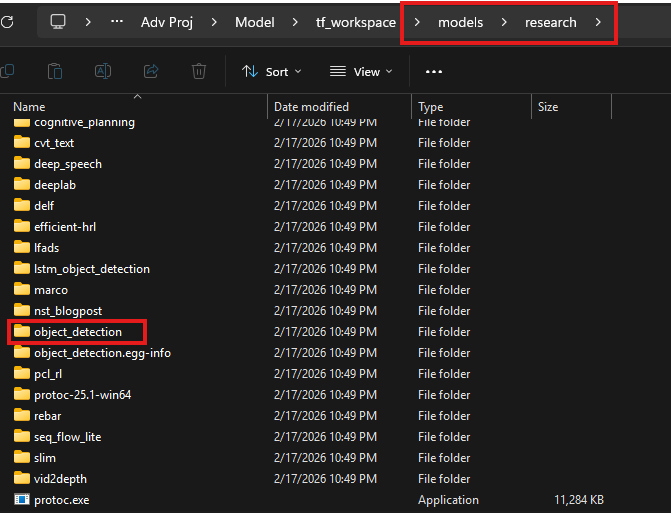
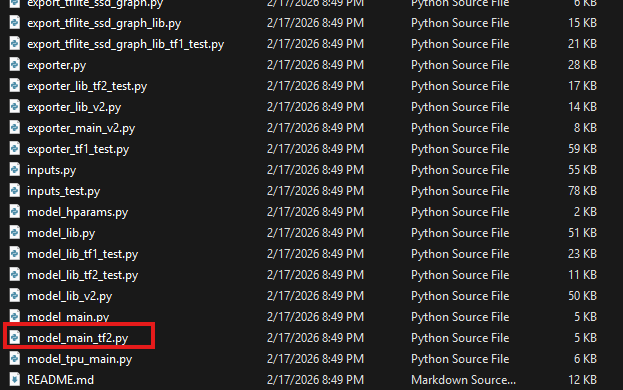
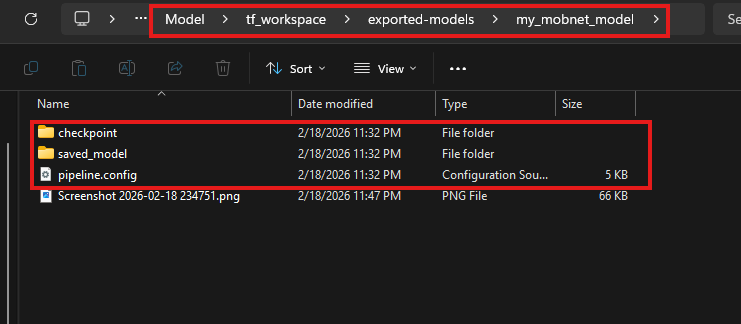

INSTALL DETECTION API
Lets say you Have Everything as you needed for Enviroment Dependency to work

you Need the Detection API to work so
Compile the protobuf files to initialize the library.
Install the research package to your environment.

In [ ]:
Terminal Command Example:

cd models/research
protoc object_detection/protos/*.proto --python_out=.
cp object_detection/packages/tf2/setup.py .
python -m pip install . # this is just incase if this Dinosour is NOT Broken (dont have to run this line)

CONFIGURE PIPELINE
Open the pipeline.config file to adjust settings.
Update num_classes to 3 for safe, phone, and texting categories.
Modify fine_tune_checkpoint_type to detection.
Ensure all local paths point to your dataset and label map.

# as Example:

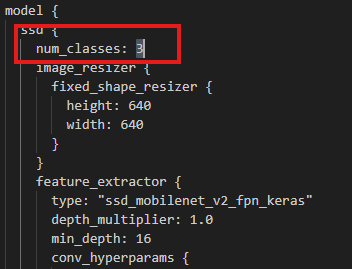
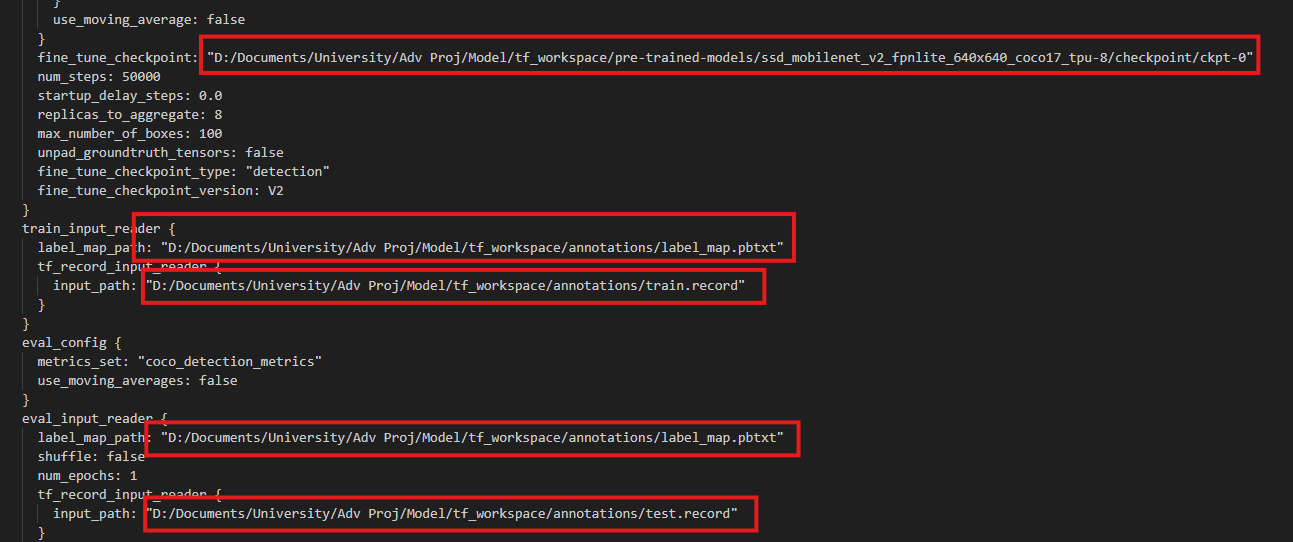

Set fine_tune_checkpoint to the legacy coco model path
Change fine_tune_checkpoint_type to detection
Link label_map_path to the local pbtxt file

TRAIN THE MODEL
Run the training script.
This step often triggers hardware barriers or dependency loops.
Monitor the terminal for version mismatches or initialization failures

In [ ]:
TERMINAL:

python model_main_tf2.py

--model_dir=models/my_ssd_v2

--pipeline_config_path=pipeline.config

This workflow represents the 10 day struggle to produce a working architecture which is after Train that it! (it does Look abit Easy and Not too Hard but the Pain is the Obstacle of Dependency of libiary!)

(Keep in mind Expected for CUDA FAILED inorder to make the "Training" work You have to Download the Cuda ToolKit which need to Compatible with That Python in that spicific Enviroment and you have to Replace to Protoc.exe inside inorder to work)

More context: It would be EASIER. IF the Google Colab that this Model Design to be able to run is still Function but sadly, it's dead!

---

# YOLOv8 Setup

This implementation represents the transition to a high-performance architecture. Development concluded in 6 hours due to the stability of modern libraries. Unlike the legacy model, this system avoids version conflicts and dependency loops.

CELL 1: MODERN ENVIRONMENT SETUP
Assume that you have the Ultralytics

accroding to yolo.ipynb from "Model" Folder the Code should be like this

In [ ]:
from ultralytics import YOLO

# Load the model
# 'yolov8n.pt' is the Nano version. It is the fastest.
# You can change it to 'yolov8s.pt' (Small) or 'yolov8m.pt' (Medium) later for better accuracy.
model = YOLO("yolov8s.pt") 

# Train the model
results = model.train(
    data=r"D:\Documents\University\Adv Proj\Dataset\yolo\CV-Driver-Distraction-V1.0\data.yaml",  # Points to your downloaded data
    epochs=50,                                                                          # Train for cycles
    imgsz=640,                                                                          # Image size
    batch=16,                                                                           # Batch size
    device=0,                                                                           # GPU index
    workers=4,                                                                          # Multiple workers for data loading
    project=r"D:\Documents\University\Adv Proj\Train Model\YOLO\V1.0",                 # Save results to this project folder
    name="yolo_driver_v1.0"                                                             # Name of this training run
)

with everything else it would Be easy you can just Press Run and Enjoy

Now lets say Everything Work out you Now Have 2 Model that Already Train

This Time you have to locate the Model trained as example Below:

# SSDMobileNetV2
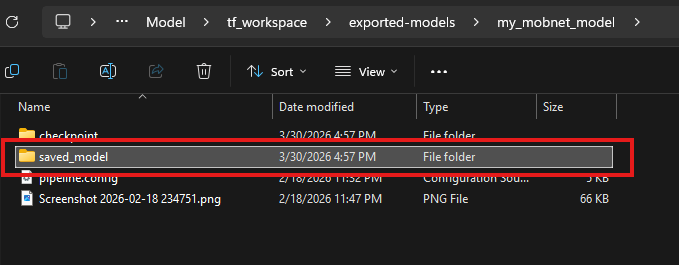

# Yolov8
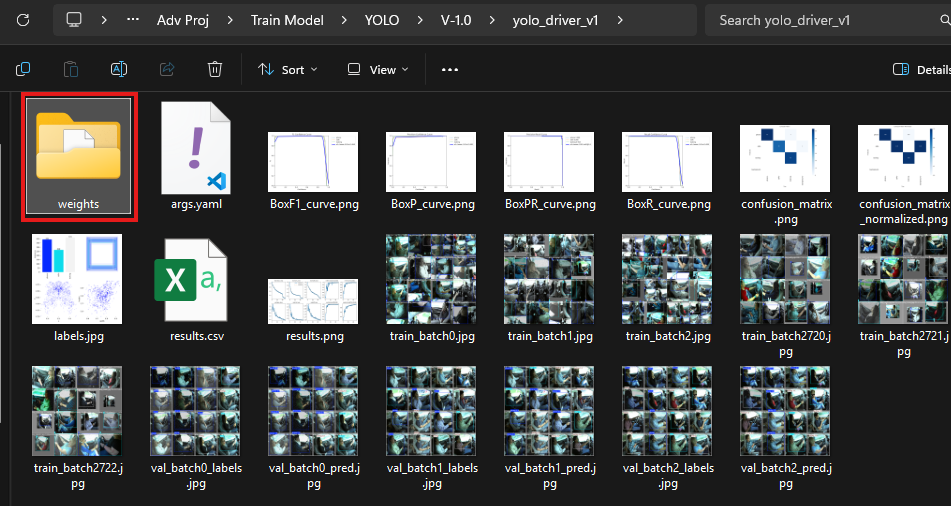


Now since we Locate Most of Trained Model now were Gonna Do some Logging while Output the Clip to see if it sees the Boxes!

# Accroding YOLOv8 and log detection.ipynb

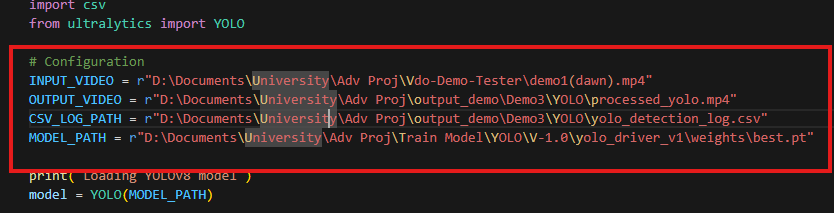

Just change the Path to be the Excact what you want and Link the Model correctly with this it Run Correctly Fine which will Output Using OpenCV with an csv file of 4000+ Frame ID of Log with Speed and accuracy and the class label identifyer.

# Same as SSDMobileNetV2

using SSDMobileNetV2 and log detection.ipynb

by image below

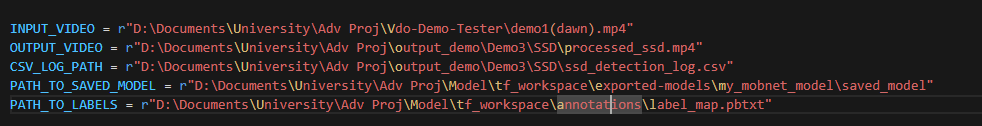

# That it!

you have Done Everything that include!

now that the Deployment for Local Host

In [ ]:
With app.py you can easily Run it (REQUIRE TERMINAL)

using:

streamlit run app.py

with the excact File Location when In terminal or else that you Wouldn't able to find the File to run

And That it! Viola!

that all the Part!